<a href="https://colab.research.google.com/github/FALAA-1285/Pembelajaran-Mesin-2026/blob/main/Pertemuan%204/Tugas%20Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas 1 – K-Means
Buatlah sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
3. Buatlah model K-Means dengan mempertimbangkan jumlah
k yang terbaik.


### Soal 1 – Gunakan data 'Mall_Customers.csv'

**Langkah 1 – Import Library**

In [11]:
# Import required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

**Langkah 2 – Load dan Inspeksi Data**

In [12]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Terdapat 200 data dan tidak ada *missing values* pada seluruh variabel.

### Soal 2 – Tentukan fitur yang tepat untuk clustering (minimal 2)

**Langkah 3 – Seleksi Fitur**


In [14]:
# Features Selection
X = df.iloc[:, 3:5]  # Annual Income (k$) dan Spending Score (1-100)
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


**Langkah 4 – Plotting**

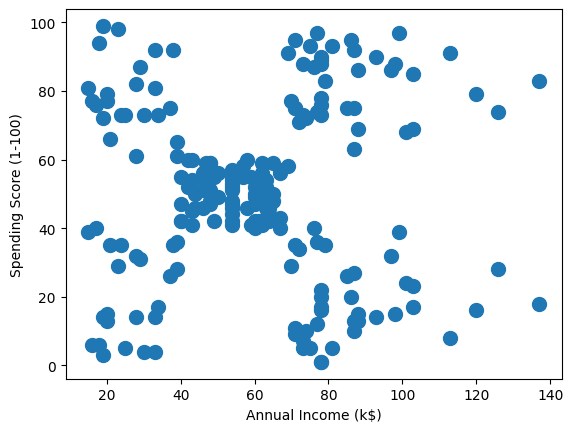

In [15]:
# Make a scatterplot using
# Annual Income and Spending Score
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)
plt.show()

### Soal 3 – Buat model K-Means dengan jumlah k terbaik

**Langkah 5 – Menentukan k terbaik dengan Elbow Method**

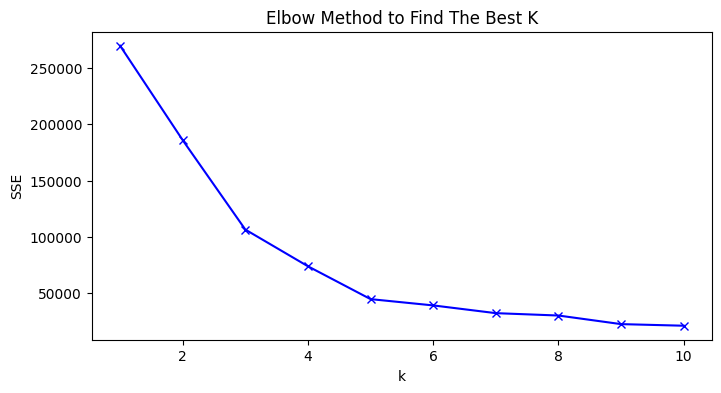

In [16]:
# Find the best k
# using Elbow Method

# List SSE values
sse = []

# Build k range from 1 to 10
K = range(1, 11)

# Find the SSE value for each k
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Elbow Method to Find The Best K")
plt.show()

Berdasarkan grafik Elbow, nilai SSE turun tajam hingga **k = 5**, kemudian penurunannya mulai landai.

**Langkah 6 – Membuat Model K-Means (k = 5)**

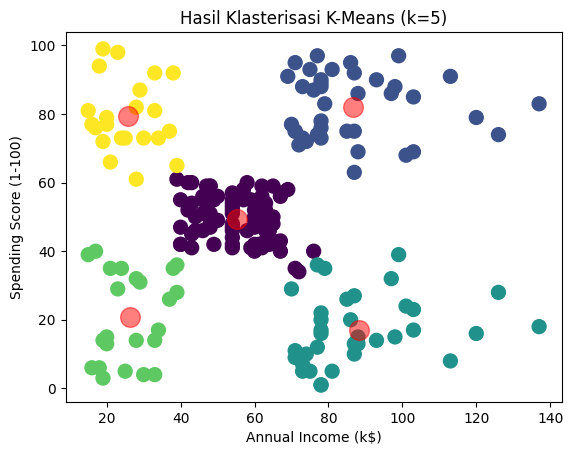

In [17]:
# Initiate K-Means object with number of cluster is 5
cl_kmeans = KMeans(n_clusters=5, random_state=0)

# Fit and predict
y_kmeans = cl_kmeans.fit_predict(X)

# Plot the clustering result
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot the centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Klasterisasi K-Means (k=5)')
plt.show()

**Langkah 7 – Evaluasi Model**

In [18]:
from sklearn.metrics import silhouette_score

# Print SSE and Silhouette value
print(f'Nilai SSE: {cl_kmeans.inertia_}')
print(f'Silhouette Score: {silhouette_score(X, y_kmeans)}')

Nilai SSE: 44448.45544793369
Silhouette Score: 0.553931997444648


## Tugas 2 – DBSCAN

1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
   - eps = 0.05, 0.1, 0.3, 0.5
   - min_samples = 3, 10, 20
   - Catat perubahan klaster, noise, dan kualitas evaluasi.

### Soal 1 – Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi

**Langkah 0 – Import Library**

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

**Langkah 1 – Membuat Dataset Sintetis dan Normalisasi**

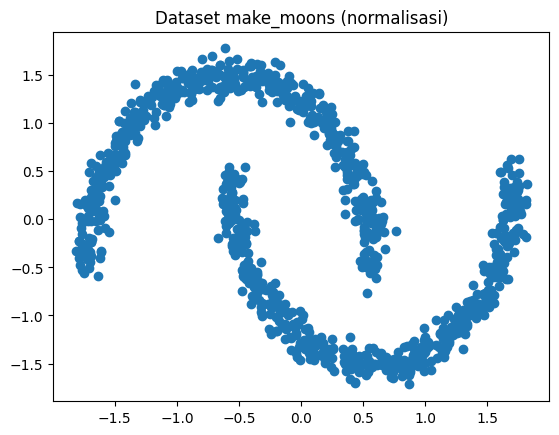

In [20]:
X, y = make_moons(1000, noise=.05, random_state=0)

# Normalisasi data
X = StandardScaler().fit_transform(X)

plt.scatter(X[:, 0], X[:, 1])
plt.title('Dataset make_moons (normalisasi)')
plt.show()

### Soal 2 – Jalankan DBSCAN (eps=0.2, min_samples=5), hitung jumlah klaster & noise

In [21]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
cluster_db = dbscan.fit_predict(X)

n_cluster = len(set(cluster_db)) - (1 if -1 in cluster_db else 0)
n_noise = list(cluster_db).count(-1)

print('Jumlah klaster:', n_cluster)
print('Jumlah noise  :', n_noise)

Jumlah klaster: 2
Jumlah noise  : 0


### Soal 3 – Evaluasi dengan Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette

In [22]:
print('Homogeneity :', metrics.homogeneity_score(y, cluster_db))
print('Completeness:', metrics.completeness_score(y, cluster_db))
print('V-measure   :', metrics.v_measure_score(y, cluster_db))
print('ARI         :', metrics.adjusted_rand_score(y, cluster_db))
print('AMI         :', metrics.adjusted_mutual_info_score(y, cluster_db))
print('Silhouette  :', metrics.silhouette_score(X, cluster_db))

Homogeneity : 1.0
Completeness: 1.0
V-measure   : 1.0
ARI         : 1.0
AMI         : 1.0
Silhouette  : 0.3915969903000845


### Soal 4 – Visualisasi hasil DBSCAN (core = titik besar, non-core = titik kecil, noise = hitam)

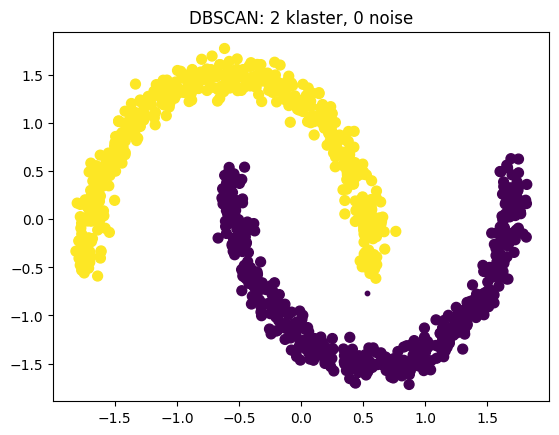

In [23]:
# Menandai core sample
core = np.zeros_like(cluster_db, dtype=bool)
core[dbscan.core_sample_indices_] = True

noise = cluster_db == -1

# core sample (titik besar)
plt.scatter(X[core, 0], X[core, 1], c=cluster_db[core], cmap='viridis', s=50)
# non-core (titik kecil)
plt.scatter(X[~core & ~noise, 0], X[~core & ~noise, 1], c=cluster_db[~core & ~noise], cmap='viridis', s=10)
# noise (hitam)
plt.scatter(X[noise, 0], X[noise, 1], c='black', s=10)

plt.title(f'DBSCAN: {n_cluster} klaster, {n_noise} noise')
plt.show()

### Soal 5 – Eksperimen eps = 0.05, 0.1, 0.3, 0.5 dan min_samples = 3, 10, 20

In [24]:
for eps in [0.05, 0.1, 0.3, 0.5]:
    for ms in [3, 10, 20]:
        cluster_db = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        n_cluster = len(set(cluster_db)) - (1 if -1 in cluster_db else 0)
        n_noise = list(cluster_db).count(-1)

        print(f'eps={eps}, min_samples={ms}')
        print('  Klaster     :', n_cluster)
        print('  Noise       :', n_noise)
        print('  Homogeneity :', round(metrics.homogeneity_score(y, cluster_db), 3))
        print('  Completeness:', round(metrics.completeness_score(y, cluster_db), 3))
        print('  V-measure   :', round(metrics.v_measure_score(y, cluster_db), 3))
        print('  ARI         :', round(metrics.adjusted_rand_score(y, cluster_db), 3))
        print('  AMI         :', round(metrics.adjusted_mutual_info_score(y, cluster_db), 3))
        if n_cluster > 1:
            print('  Silhouette  :', round(metrics.silhouette_score(X, cluster_db), 3))
        print()

eps=0.05, min_samples=3
  Klaster     : 67
  Noise       : 197
  Homogeneity : 0.804
  Completeness: 0.155
  V-measure   : 0.26
  ARI         : 0.033
  AMI         : 0.246
  Silhouette  : 0.078

eps=0.05, min_samples=10
  Klaster     : 0
  Noise       : 1000
  Homogeneity : 0.0
  Completeness: 1.0
  V-measure   : 0.0
  ARI         : 0.0
  AMI         : 0.0

eps=0.05, min_samples=20
  Klaster     : 0
  Noise       : 1000
  Homogeneity : 0.0
  Completeness: 1.0
  V-measure   : 0.0
  ARI         : 0.0
  AMI         : 0.0

eps=0.1, min_samples=3
  Klaster     : 3
  Noise       : 18
  Homogeneity : 0.983
  Completeness: 0.708
  V-measure   : 0.824
  ARI         : 0.854
  AMI         : 0.823
  Silhouette  : 0.138

eps=0.1, min_samples=10
  Klaster     : 9
  Noise       : 63
  Homogeneity : 0.939
  Completeness: 0.358
  V-measure   : 0.519
  ARI         : 0.435
  AMI         : 0.517
  Silhouette  : 0.184

eps=0.1, min_samples=20
  Klaster     : 6
  Noise       : 844
  Homogeneity : 0.157
  Co

**Catatan Hasil Eksperimen**

| eps | min_samples | Klaster | Noise | Homogeneity | Completeness | V-measure | ARI | AMI | Silhouette |
|---|---|---|---|---|---|---|---|---|---|
| 0.05 | 3 | 67 | 197 | 0.804 | 0.155 | 0.260 | 0.033 | 0.246 | 0.078 |
| 0.05 | 10 | 0 | 1000 | 0.0 | 1.0 | 0.0 | 0.0 | 0.0 | - |
| 0.05 | 20 | 0 | 1000 | 0.0 | 1.0 | 0.0 | 0.0 | 0.0 | - |
| 0.1 | 3 | 3 | 18 | 0.983 | 0.708 | 0.824 | 0.854 | 0.823 | 0.138 |
| 0.1 | 10 | 9 | 63 | 0.939 | 0.358 | 0.519 | 0.435 | 0.517 | 0.184 |
| 0.1 | 20 | 6 | 844 | 0.157 | 0.153 | 0.155 | 0.010 | 0.152 | -0.409 |
| 0.3 | 3 | 2 | 0 | 1.0 | 1.0 | 1.0 | 1.0 | 1.0 | 0.392 |
| 0.3 | 10 | 2 | 0 | 1.0 | 1.0 | 1.0 | 1.0 | 1.0 | 0.392 |
| 0.3 | 20 | 2 | 0 | 1.0 | 1.0 | 1.0 | 1.0 | 1.0 | 0.392 |
| 0.5 | 3 | 1 | 0 | 0.0 | 1.0 | 0.0 | 0.0 | 0.0 | - |
| 0.5 | 10 | 1 | 0 | 0.0 | 1.0 | 0.0 | 0.0 | 0.0 | - |
| 0.5 | 20 | 2 | 0 | 0.990 | 0.990 | 0.990 | 0.996 | 0.990 | 0.393 |

**Analisis:**
1. **eps = 0.05** terlalu kecil: data terpecah menjadi 67 klaster kecil dengan 197 noise (min_samples=3), bahkan seluruh data (1000) menjadi noise saat min_samples=10 dan 20. Kualitas evaluasi sangat buruk.
2. **eps = 0.1** masih kurang: klaster terbentuk lebih dari 2 dan noise bertambah seiring naiknya min_samples (18 → 63 → 844). ARI turun dari 0.854 menjadi 0.010.
3. **eps = 0.3** paling optimal: untuk semua min_samples terbentuk tepat 2 klaster tanpa noise, dengan nilai Homogeneity, Completeness, V-measure, ARI, dan AMI = 1.0 (sama seperti eps=0.2, min_samples=5).
4. **eps = 0.5** terlalu besar: kedua bulan sabit menyatu menjadi 1 klaster (min_samples=3 dan 10). Hanya min_samples=20 yang masih mampu memisahkan menjadi 2 klaster.
5. **Pengaruh min_samples:** semakin besar min_samples, syarat menjadi core point semakin ketat sehingga noise bertambah (pada eps kecil) atau klaster yang menyatu bisa terpisah kembali (pada eps besar).
6. **Silhouette** maksimal hanya sekitar 0.39 walaupun klasterisasi sudah sempurna, karena silhouette kurang cocok untuk data non-linear seperti make_moons.